In [153]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

In [155]:
import os
import sys

import io
from io import BytesIO
import csv

import google.auth
from google.cloud import bigquery
#from google.cloud import bigquery_storage

In [157]:
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "./market-analysis-project-91130-9f9a036682b6.json"

credentials, project_id = google.auth.default(
    scopes=["https://www.googleapis.com/auth/cloud-platform"]
)

bqclient = bigquery.Client(credentials=credentials, project=project_id,)

In [159]:

sql = f"""
select * from tmp1.stckln_amz_mattress_ms_trend 
"""

df = bqclient.query(sql).to_dataframe()

In [161]:
print(df)

       RetailerSku         category    subcategory profile   size  \
0       B07KNGW8BX  Spring Mattress        Bonnell       8   Full   
1       B07KNGW8BX  Spring Mattress        Bonnell       8   Full   
2       B09JP9N6GL  Spring Mattress        Bonnell      12  Queen   
3       B0D8Q1VNN8  Spring Mattress        Bonnell       6   Twin   
4       B0BBHF5321  Spring Mattress        Bonnell       8   Full   
...            ...              ...            ...     ...    ...   
518298  B0DLGTYD9Q  Spring Mattress  Pocket Spring      10   Twin   
518299  B0DLGTYD9Q  Spring Mattress  Pocket Spring      10   Twin   
518300  B0DLGGCVSH  Spring Mattress  Pocket Spring      12   Twin   
518301  B0DLGGCVSH  Spring Mattress  Pocket Spring      12   Twin   
518302  B0C6B7QP7L             null           null    null  Queen   

       bsr_ctgry_label Brand_raw Brand_adj  \
0       01. Mattresses   SOMETTE   SOMETTE   
1       01. Mattresses   SOMETTE   SOMETTE   
2       01. Mattresses     NUTAN 

In [163]:
df['RetailerSku'].nunique()

23253

In [165]:
df['Brand_raw'].nunique()

884

In [167]:
# WeekEnding이 object 타입이라면 datetime으로 변환
df['WeekEnding'] = pd.to_datetime(df['WeekEnding'], errors='coerce')

# 연도 컬럼 추가
df['year'] = df['WeekEnding'].dt.year
df['year'].isna().sum()

0

In [173]:
df['yr_half'] = df['yr_month'].apply(
    lambda ym: f"{ym.split('-')[0]}-H1" if int(ym.split('-')[1]) <= 6 else f"{ym.split('-')[0]}-H2"
)

In [175]:
df

,RetailerSku,category,subcategory,profile,size,bsr_ctgry_label,Brand_raw,Brand_adj,Title,WeekEnding,...,UnitsSold,RetailPrice,yr_quarter,yr_month,yr_week,week_str,retailsales_ctgry_brand,retailsales_ctgry_brand_by_6month,year,yr_half
0,B07KNGW8BX,Spring Mattress,Bonnell,8,Full,01. Mattresses,SOMETTE,SOMETTE,#6000 276 Coil Hinged Full Mattress Suede Navy...,2024-05-25,...,5,226.49,24-2,24-05,Y24 W21,Y24 W21,5564.07,0.00,2024,24-H1
1,B07KNGW8BX,Spring Mattress,Bonnell,8,Full,01. Mattresses,SOMETTE,SOMETTE,#6000 276 Coil Hinged Full Mattress Suede Navy...,2023-05-20,...,6,269.90,23-2,23-05,Y23 W20,Y23 W20,5564.07,0.00,2023,23-H1
2,B09JP9N6GL,Spring Mattress,Bonnell,12,Queen,01. Mattresses,NUTAN,NUTAN,12-Inch Medium Plush Double Sided Pillowtop In...,2024-02-17,...,1,535.91,24-1,24-02,Y24 W07,Y24 W07,1777370.72,57507.28,2024,24-H1
3,B0D8Q1VNN8,Spring Mattress,Bonnell,6,Twin,01. Mattresses,OUUI,OUUI,"6 Inch Foam and Spring Hybrid Mattress, Fiberg...",2025-01-25,...,2,119.99,25-1,25-01,Y25 W04,Y25 W04,7940523.10,1119589.42,2025,25-H1
4,B0BBHF5321,Spring Mattress,Bonnell,8,Full,01. Mattresses,BIZCHAIR,BIZCHAIR,8 Inch CertiPUR-US Certified Spring Hybrid Mat...,2025-02-01,...,1,129.99,25-1,25-01,Y25 W05,Y25 W05,345848.68,51044.64,2025,25-H1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
518298,B0DLGTYD9Q,Spring Mattress,Pocket Spring,10,Twin,01. Mattresses,WOOD-IT,WOOD-IT,"wOod-it Twin Size Mattress, 10 Inch Twin Mattr...",2024-11-16,...,76,69.99,24-4,24-11,Y24 W46,Y24 W46,2862281.93,38397.37,2024,24-H2
518299,B0DLGTYD9Q,Spring Mattress,Pocket Spring,10,Twin,01. Mattresses,WOOD-IT,WOOD-IT,"wOod-it Twin Size Mattress, 10 Inch Twin Mattr...",2024-11-09,...,2,150.13,24-4,24-11,Y24 W45,Y24 W45,2862281.93,38397.37,2024,24-H2
518300,B0DLGGCVSH,Spring Mattress,Pocket Spring,12,Twin,01. Mattresses,WOOD-IT,WOOD-IT,"wOod-it Twin Size Mattress, 12 Inch Twin Mattr...",2024-11-09,...,2,250.05,24-4,24-11,Y24 W45,Y24 W45,2862281.93,38397.37,2024,24-H2
518301,B0DLGGCVSH,Spring Mattress,Pocket Spring,12,Twin,01. Mattresses,WOOD-IT,WOOD-IT,"wOod-it Twin Size Mattress, 12 Inch Twin Mattr...",2024-11-16,...,2,199.99,24-4,24-11,Y24 W46,Y24 W46,2862281.93,38397.37,2024,24-H2


### 1. 기초 데이터 분석 - Mattress 카테고리

#### - 2025년 기준

In [215]:
df1 = df.copy()
df_2025 = df1[df1['year'] == 2025].copy()

In [53]:
# Brand_raw별 매출 합계 집계
asin_sales_2025 = (
    df_2025.groupby('RetailerSku')['RetailSales']
           .sum()
           .reset_index()
           .sort_values(by='RetailSales', ascending=False)
)

# 전체 매출 합계
total_sales = asin_sales_2025['RetailSales'].sum()

# 비율(Ratio) 계산
asin_sales_2025['Ratio'] = asin_sales_2025['RetailSales'] / total_sales

# 누적 비율(Cumul) 계산
asin_sales_2025['Cumul'] = asin_sales_2025['Ratio'].cumsum()

print(asin_sales_2025)

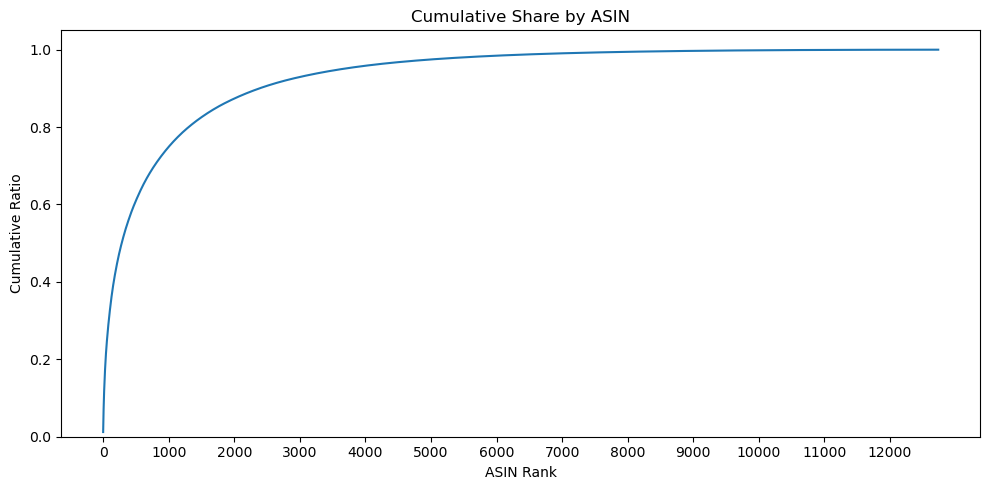

In [79]:
# x축 숫자 라벨 생성 (1부터 시작)
x_labels = list(range(0, len(asin_sales_2025)))

# 누적 점유율 그래프
plt.figure(figsize=(10, 5))
plt.plot(x_labels, asin_sales_2025['Cumul'])
plt.title("Cumulative Share by ASIN")
plt.xlabel("ASIN Rank")
plt.ylabel("Cumulative Ratio")
plt.ylim(0, 1.05)

# x축 라벨을 100 단위로 설정
step = 1000
plt.xticks(ticks=x_labels[::step], labels=x_labels[::step])

plt.tight_layout()
plt.show()

In [57]:
asin_sales_2025.to_csv('asin_sales_2025.csv', index=False)

In [63]:
# 2025년 데이터 필터링
df_2025 = df[df['year'] == 2025].copy()

# Brand_raw별 매출 합계 집계
brand_sales_2025 = (
    df_2025.groupby('Brand_raw')['RetailSales']
           .sum()
           .reset_index()
           .sort_values(by='RetailSales', ascending=False)
)

# 전체 매출 합계
total_sales = brand_sales_2025['RetailSales'].sum()

# 비율(Ratio) 계산
brand_sales_2025['Ratio'] = brand_sales_2025['RetailSales'] / total_sales

# 누적 비율(Cumul) 계산
brand_sales_2025['Cumul'] = brand_sales_2025['Ratio'].cumsum()
print(brand_sales_2025)

       Brand_raw   RetailSales         Ratio     Cumul
610        ZINUS  1.401663e+08  1.614926e-01  0.161493
386      NOVILLA  6.276125e+07  7.231037e-02  0.233803
168          FDW  3.963378e+07  4.566406e-02  0.279467
352        MLILY  3.545190e+07  4.084590e-02  0.320313
375       NECTAR  3.312092e+07  3.816027e-02  0.358473
..           ...           ...           ...       ...
547      THINMAY  4.999000e+01  5.759598e-08  1.000000
217       HOKWAY  4.999000e+01  5.759598e-08  1.000000
324   MASTERMARK  4.299000e+01  4.953093e-08  1.000000
90       COCOARM  3.412000e+01  3.931136e-08  1.000000
331  MAXXI CLEAN  2.600000e+01  2.995590e-08  1.000000

[619 rows x 4 columns]


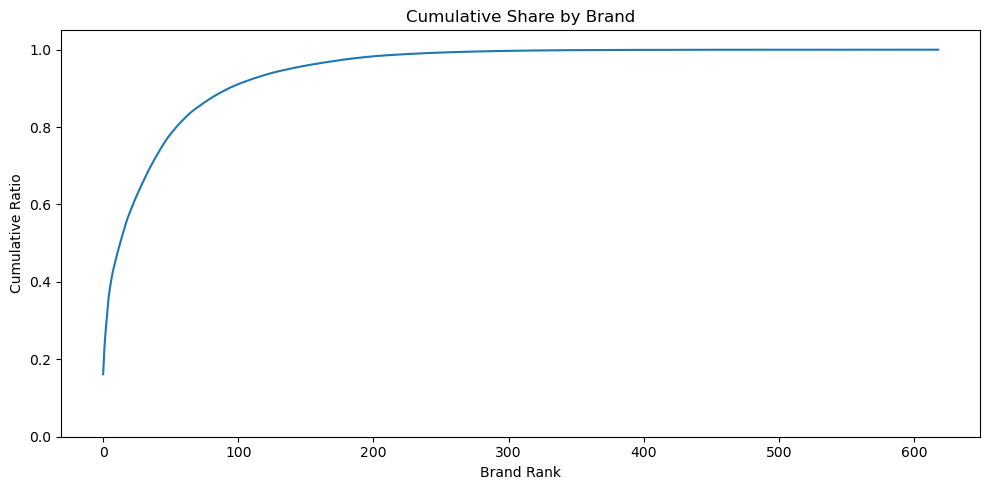

In [83]:
# x축 숫자 라벨 생성 (1부터 시작)
x_labels = list(range(0, len(brand_sales_2025)))

# 누적 점유율 그래프
plt.figure(figsize=(10, 5))
plt.plot(x_labels, brand_sales_2025['Cumul'])
plt.title("Cumulative Share by Brand")
plt.xlabel("Brand Rank")
plt.ylabel("Cumulative Ratio")
plt.ylim(0, 1.05)

# x축 라벨을 100 단위로 설정
step = 100
plt.xticks(ticks=x_labels[::step], labels=x_labels[::step])

plt.tight_layout()
plt.show()

In [45]:
print(brand_sales_2025)

       Brand_raw   RetailSales         Ratio     Cumul
610        ZINUS  1.401663e+08  1.614926e-01  0.161493
386      NOVILLA  6.276125e+07  7.231037e-02  0.233803
168          FDW  3.963378e+07  4.566406e-02  0.279467
352        MLILY  3.545190e+07  4.084590e-02  0.320313
375       NECTAR  3.312092e+07  3.816027e-02  0.358473
..           ...           ...           ...       ...
547      THINMAY  4.999000e+01  5.759598e-08  1.000000
217       HOKWAY  4.999000e+01  5.759598e-08  1.000000
324   MASTERMARK  4.299000e+01  4.953093e-08  1.000000
90       COCOARM  3.412000e+01  3.931136e-08  1.000000
331  MAXXI CLEAN  2.600000e+01  2.995590e-08  1.000000

[619 rows x 4 columns]


### 2. 시장 규모 추이

In [177]:
df1 = df.copy()

In [179]:
df1

,RetailerSku,category,subcategory,profile,size,bsr_ctgry_label,Brand_raw,Brand_adj,Title,WeekEnding,...,UnitsSold,RetailPrice,yr_quarter,yr_month,yr_week,week_str,retailsales_ctgry_brand,retailsales_ctgry_brand_by_6month,year,yr_half
0,B07KNGW8BX,Spring Mattress,Bonnell,8,Full,01. Mattresses,SOMETTE,SOMETTE,#6000 276 Coil Hinged Full Mattress Suede Navy...,2024-05-25,...,5,226.49,24-2,24-05,Y24 W21,Y24 W21,5564.07,0.00,2024,24-H1
1,B07KNGW8BX,Spring Mattress,Bonnell,8,Full,01. Mattresses,SOMETTE,SOMETTE,#6000 276 Coil Hinged Full Mattress Suede Navy...,2023-05-20,...,6,269.90,23-2,23-05,Y23 W20,Y23 W20,5564.07,0.00,2023,23-H1
2,B09JP9N6GL,Spring Mattress,Bonnell,12,Queen,01. Mattresses,NUTAN,NUTAN,12-Inch Medium Plush Double Sided Pillowtop In...,2024-02-17,...,1,535.91,24-1,24-02,Y24 W07,Y24 W07,1777370.72,57507.28,2024,24-H1
3,B0D8Q1VNN8,Spring Mattress,Bonnell,6,Twin,01. Mattresses,OUUI,OUUI,"6 Inch Foam and Spring Hybrid Mattress, Fiberg...",2025-01-25,...,2,119.99,25-1,25-01,Y25 W04,Y25 W04,7940523.10,1119589.42,2025,25-H1
4,B0BBHF5321,Spring Mattress,Bonnell,8,Full,01. Mattresses,BIZCHAIR,BIZCHAIR,8 Inch CertiPUR-US Certified Spring Hybrid Mat...,2025-02-01,...,1,129.99,25-1,25-01,Y25 W05,Y25 W05,345848.68,51044.64,2025,25-H1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
518298,B0DLGTYD9Q,Spring Mattress,Pocket Spring,10,Twin,01. Mattresses,WOOD-IT,WOOD-IT,"wOod-it Twin Size Mattress, 10 Inch Twin Mattr...",2024-11-16,...,76,69.99,24-4,24-11,Y24 W46,Y24 W46,2862281.93,38397.37,2024,24-H2
518299,B0DLGTYD9Q,Spring Mattress,Pocket Spring,10,Twin,01. Mattresses,WOOD-IT,WOOD-IT,"wOod-it Twin Size Mattress, 10 Inch Twin Mattr...",2024-11-09,...,2,150.13,24-4,24-11,Y24 W45,Y24 W45,2862281.93,38397.37,2024,24-H2
518300,B0DLGGCVSH,Spring Mattress,Pocket Spring,12,Twin,01. Mattresses,WOOD-IT,WOOD-IT,"wOod-it Twin Size Mattress, 12 Inch Twin Mattr...",2024-11-09,...,2,250.05,24-4,24-11,Y24 W45,Y24 W45,2862281.93,38397.37,2024,24-H2
518301,B0DLGGCVSH,Spring Mattress,Pocket Spring,12,Twin,01. Mattresses,WOOD-IT,WOOD-IT,"wOod-it Twin Size Mattress, 12 Inch Twin Mattr...",2024-11-16,...,2,199.99,24-4,24-11,Y24 W46,Y24 W46,2862281.93,38397.37,2024,24-H2


In [209]:
df1.groupby(['year'])['RetailSales'].sum()

year
2023    1.750029e+09
2024    1.863939e+09
2025    8.679426e+08
Name: RetailSales, dtype: float64

In [119]:
df1_grp = df1.groupby(['subcategory'], as_index=False)['RetailSales'].sum()
total = df1['RetailSales'].sum()
df1_grp['Ratio'] = df1_grp['RetailSales']/total*100
print(df1_grp)

       subcategory   RetailSales      Ratio
0          Bonnell  2.169523e+08   4.840620
1  Continuous Coil  5.484140e+03   0.000122
2      Cooling/Gel  1.596857e+09  35.628929
3      Non-Cooling  8.181047e+08  18.253479
4           OTHERS  2.786398e+08   6.216987
5    Pocket Spring  1.571352e+09  35.059861
6             null  7.959000e+01   0.000002


#### 2.1 파이 차트

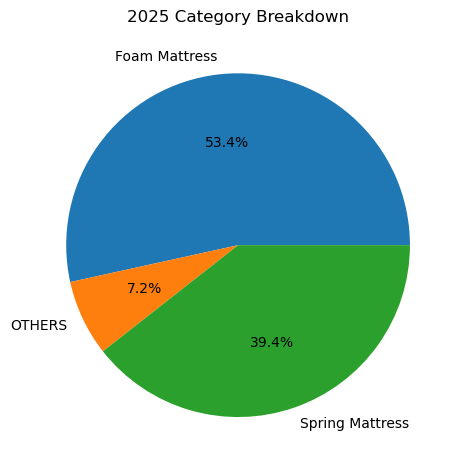

In [223]:
# 1. category별 매출 합계 집계
category_sales = df_2025.groupby('category')['RetailSales'].sum()

# 2. Pie Chart
category_sales.plot(kind='pie', autopct='%1.1f%%', ylabel='', title='2025 Category Breakdown')
plt.tight_layout()
plt.show()

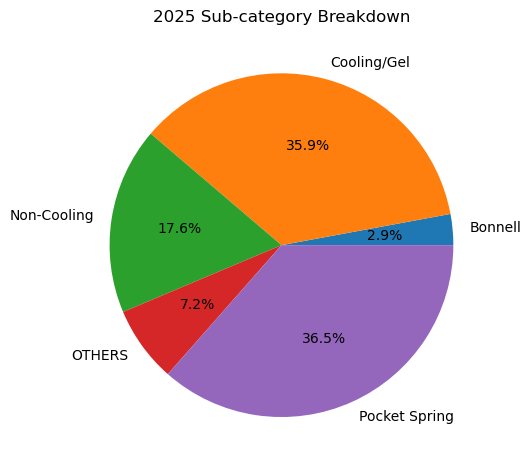

In [225]:
# 1. category별 매출 합계 집계
category_sales = df_2025.groupby('subcategory')['RetailSales'].sum()

# 2. Pie Charts
category_sales.plot(kind='pie', autopct='%1.1f%%', ylabel='', title='2025 Sub-category Breakdown')
plt.tight_layout()
plt.show()

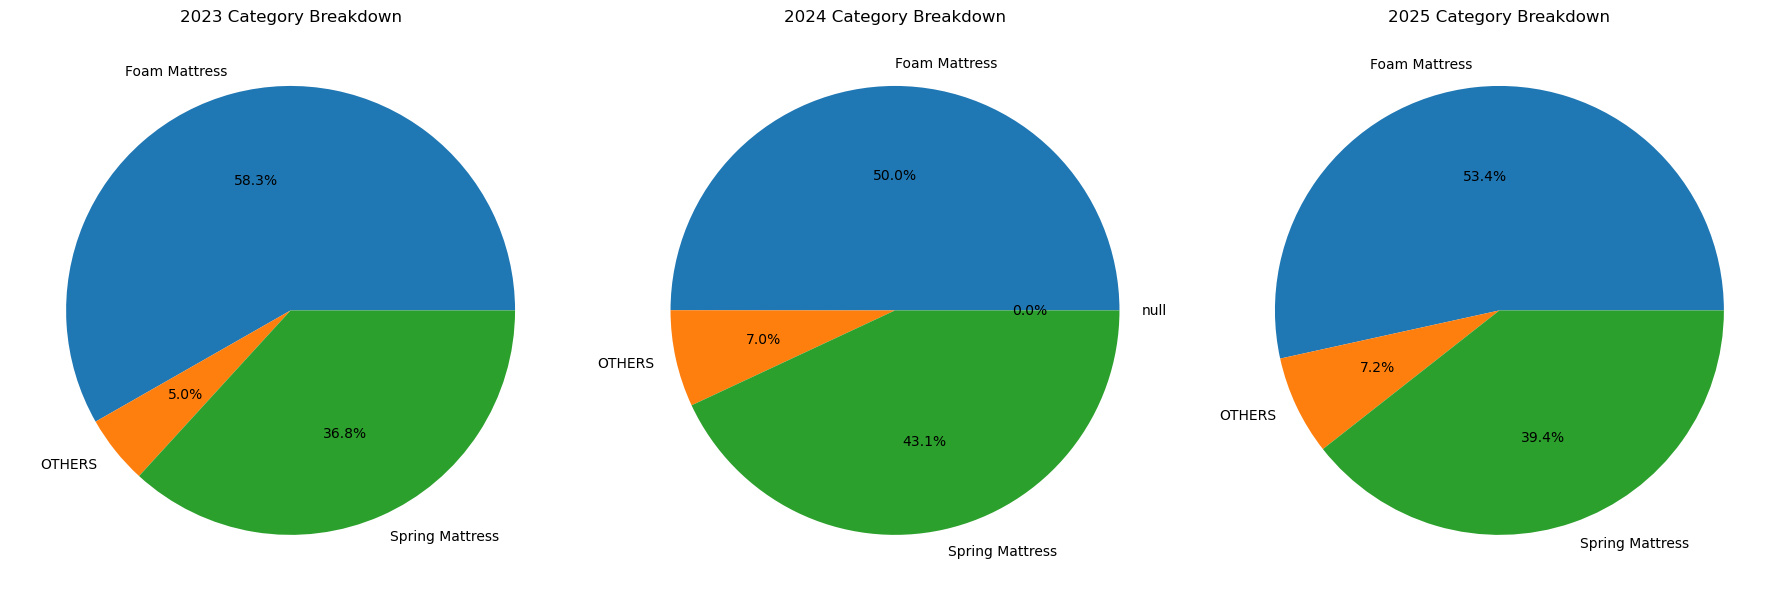

In [240]:

years = [2023, 2024, 2025]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, year in enumerate(years):
    # 해당 연도 데이터 추출
    df_year = df[df['year'] == year]
    # subcategory별 매출 합계
    category_sales = df_year.groupby('category')['RetailSales'].sum()
    
    # 파이차트 그리기
    category_sales.plot(
        kind='pie',
        autopct='%1.1f%%',
        ylabel='',
        title=f'{year} Category Breakdown',
        ax=axes[i]
    )

plt.tight_layout()
plt.show()

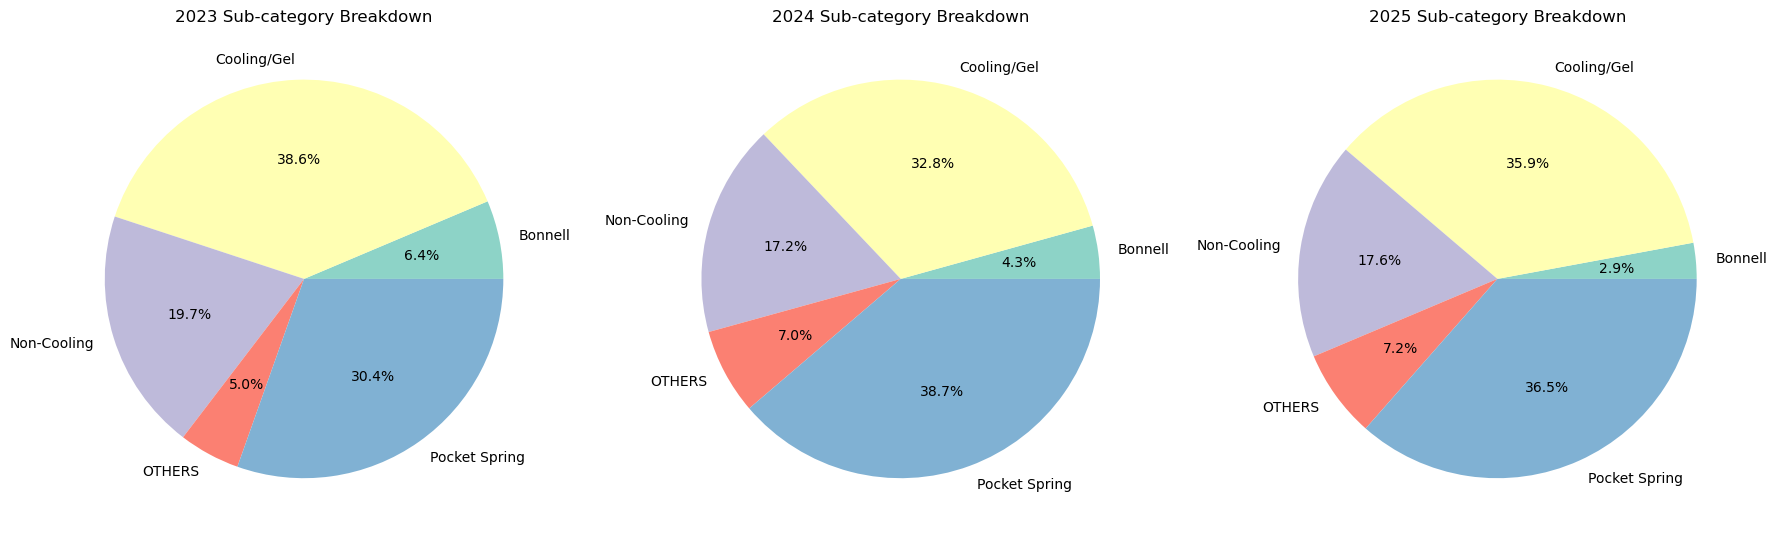

In [238]:
# 연도별 데이터 필터링 및 집계
years = [2023, 2024, 2025]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 모든 subcategory 목록 생성 (특정 카테고리 및 null 값 제외)
all_subcategories = df[~df['subcategory'].isin(['Continuous Coil', 'null']) & 
                      df['subcategory'].notna()]['subcategory'].unique()
colors = plt.cm.Set3(range(len(all_subcategories)))
color_map = dict(zip(all_subcategories, colors))

for i, year in enumerate(years):
    # 해당 연도 데이터 필터링 및 특정 카테고리, null 값 제외
    df_year = df[(df['year'] == year) & 
                 (~df['subcategory'].isin(['Continuous Coil', 'null'])) &
                 (df['subcategory'].notna())]
    
    # category별 매출 합계 집계
    category_sales = df_year.groupby('subcategory')['RetailSales'].sum()
    
    # 해당 연도 subcategory에 맞는 색상 리스트 생성
    pie_colors = [color_map[cat] for cat in category_sales.index]
    
    # Pie Chart 생성
    category_sales.plot(kind='pie', 
                       ax=axes[i],
                       autopct='%1.1f%%', 
                       ylabel='', 
                       title=f'{year} Sub-category Breakdown',
                       colors=pie_colors)

plt.tight_layout()
plt.show()

#### 2.2 영역 차트

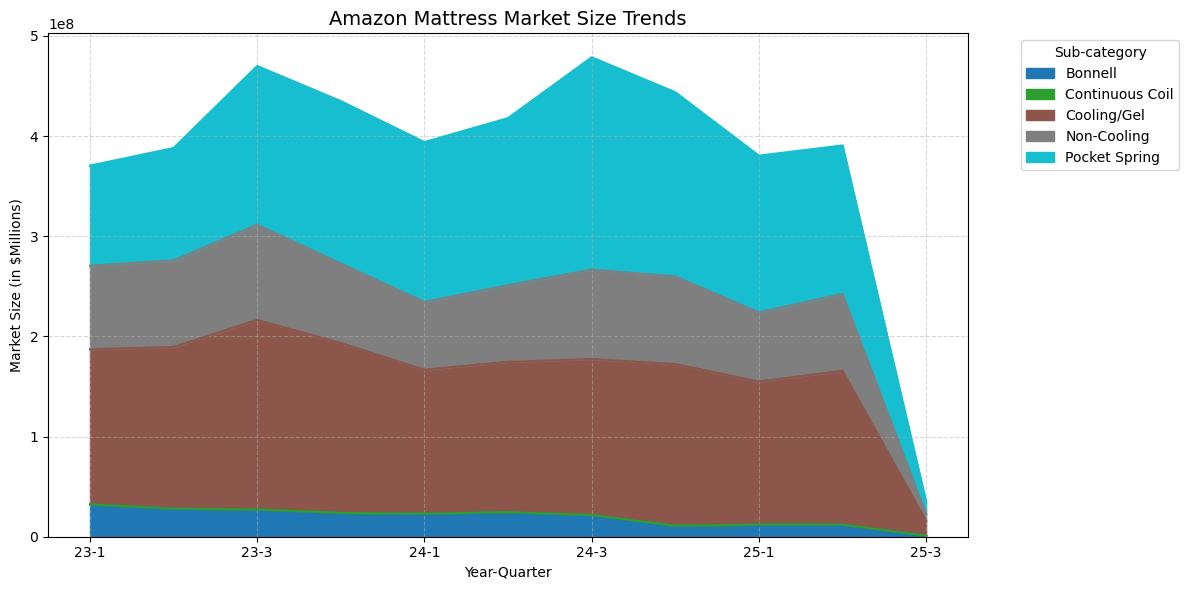

In [211]:
# 1. 'Others'와 null category 제외
df_filtered = df1[(df1['subcategory'] != 'null') & (df1['category'] != 'OTHERS')]
# 2. 세부 카테고리별 월간 매출 합계 집계
df_grouped = df_filtered.groupby(['yr_quarter', 'subcategory'])['RetailSales'].sum().unstack().fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))  # ✅ 두 개(Figure, Axes)를 반환
df_grouped.plot(kind='area', stacked=True, colormap='tab10', ax=ax)

ax.set_title('Amazon Mattress Market Size Trends', fontsize=14)
ax.set_xlabel('Year-Quarter')
ax.set_ylabel('Market Size (in $Millions)')
ax.legend(title='Sub-category', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#### 2.3 Inch별 파이차트 / 영역 차트

In [261]:
df1

,RetailerSku,category,subcategory,profile,size,bsr_ctgry_label,Brand_raw,Brand_adj,Title,WeekEnding,...,UnitsSold,RetailPrice,yr_quarter,yr_month,yr_week,week_str,retailsales_ctgry_brand,retailsales_ctgry_brand_by_6month,year,yr_half
0,B07KNGW8BX,Spring Mattress,Bonnell,8,Full,01. Mattresses,SOMETTE,SOMETTE,#6000 276 Coil Hinged Full Mattress Suede Navy...,2024-05-25,...,5,226.49,24-2,24-05,Y24 W21,Y24 W21,5564.07,0.00,2024,24-H1
1,B07KNGW8BX,Spring Mattress,Bonnell,8,Full,01. Mattresses,SOMETTE,SOMETTE,#6000 276 Coil Hinged Full Mattress Suede Navy...,2023-05-20,...,6,269.90,23-2,23-05,Y23 W20,Y23 W20,5564.07,0.00,2023,23-H1
2,B09JP9N6GL,Spring Mattress,Bonnell,12,Queen,01. Mattresses,NUTAN,NUTAN,12-Inch Medium Plush Double Sided Pillowtop In...,2024-02-17,...,1,535.91,24-1,24-02,Y24 W07,Y24 W07,1777370.72,57507.28,2024,24-H1
3,B0D8Q1VNN8,Spring Mattress,Bonnell,6,Twin,01. Mattresses,OUUI,OUUI,"6 Inch Foam and Spring Hybrid Mattress, Fiberg...",2025-01-25,...,2,119.99,25-1,25-01,Y25 W04,Y25 W04,7940523.10,1119589.42,2025,25-H1
4,B0BBHF5321,Spring Mattress,Bonnell,8,Full,01. Mattresses,BIZCHAIR,BIZCHAIR,8 Inch CertiPUR-US Certified Spring Hybrid Mat...,2025-02-01,...,1,129.99,25-1,25-01,Y25 W05,Y25 W05,345848.68,51044.64,2025,25-H1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
518298,B0DLGTYD9Q,Spring Mattress,Pocket Spring,10,Twin,01. Mattresses,WOOD-IT,WOOD-IT,"wOod-it Twin Size Mattress, 10 Inch Twin Mattr...",2024-11-16,...,76,69.99,24-4,24-11,Y24 W46,Y24 W46,2862281.93,38397.37,2024,24-H2
518299,B0DLGTYD9Q,Spring Mattress,Pocket Spring,10,Twin,01. Mattresses,WOOD-IT,WOOD-IT,"wOod-it Twin Size Mattress, 10 Inch Twin Mattr...",2024-11-09,...,2,150.13,24-4,24-11,Y24 W45,Y24 W45,2862281.93,38397.37,2024,24-H2
518300,B0DLGGCVSH,Spring Mattress,Pocket Spring,12,Twin,01. Mattresses,WOOD-IT,WOOD-IT,"wOod-it Twin Size Mattress, 12 Inch Twin Mattr...",2024-11-09,...,2,250.05,24-4,24-11,Y24 W45,Y24 W45,2862281.93,38397.37,2024,24-H2
518301,B0DLGGCVSH,Spring Mattress,Pocket Spring,12,Twin,01. Mattresses,WOOD-IT,WOOD-IT,"wOod-it Twin Size Mattress, 12 Inch Twin Mattr...",2024-11-16,...,2,199.99,24-4,24-11,Y24 W46,Y24 W46,2862281.93,38397.37,2024,24-H2


In [263]:
df1['RetailerSku'].nunique()

23253

In [265]:
profile_grp = (
    df_spring
    .groupby('profile')
    .agg(
        sku_count=('RetailerSku', 'nunique'),
        total_sales=('RetailSales', 'sum')
    )
    .reset_index()
)
print(profile_grp)

   profile  sku_count   total_sales
0     0.06          1  1.598400e+02
1      0.4          2  1.775040e+03
2      0.5          2  1.519712e+04
3     0.75          1  7.264068e+04
4        1          8  9.114790e+03
5     1.18          1  5.278800e+02
6      1.2          1  5.599600e+02
7       10       2115  5.884713e+08
8     10.5         15  1.086520e+06
9       11        142  2.466848e+07
10    11.5         23  5.114745e+06
11   11.81          1  1.079493e+05
12      12       1580  7.750665e+08
13    12.2          2  2.704305e+05
14    12.5          4  5.248202e+04
15      13         97  2.394814e+07
16    13.2          1  3.849970e+03
17    13.5         14  6.493452e+05
18      14        551  2.117752e+08
19    14.5          8  1.053227e+06
20   14.75          1  8.021650e+03
21      15         30  1.663924e+06
22    15.5          3  2.832131e+04
23      16         39  8.147288e+05
24      17          1  1.799880e+03
25      18          1  8.394000e+03
26       2         41  2.047

In [271]:
# profile이 null인 행만 필터링
df_null_profile = df_mattress[df_mattress['profile'] == 'null']

# 결과 확인 (상위 5개만 예시)
print(df_null_profile.head())

       RetailerSku         category  subcategory profile  \
1263    B0CRJYHBBV  Spring Mattress      Bonnell    null   
178688  B0CCQWBJR1    Foam Mattress  Cooling/Gel    null   
178752  B0CCK922CG    Foam Mattress  Cooling/Gel    null   
178754  B0CCK9H53L    Foam Mattress  Cooling/Gel    null   
178755  B0CCK922CD    Foam Mattress  Cooling/Gel    null   

                         size bsr_ctgry_label          Brand_raw  \
1263                     null  01. Mattresses  DREAMFOAM BEDDING   
178688  Split California King  01. Mattresses           IDEALBED   
178752                   Full  01. Mattresses           IDEALBED   
178754                  Queen  01. Mattresses           IDEALBED   
178755                Twin XL  01. Mattresses           IDEALBED   

                Brand_adj                                              Title  \
1263    DREAMFOAM BEDDING  DREAMFOAM Spring Dreams Ultra Firm Double Side...   
178688           IDEALBED  iDealBed G4 Nova Luxury Memory Foam Mattres

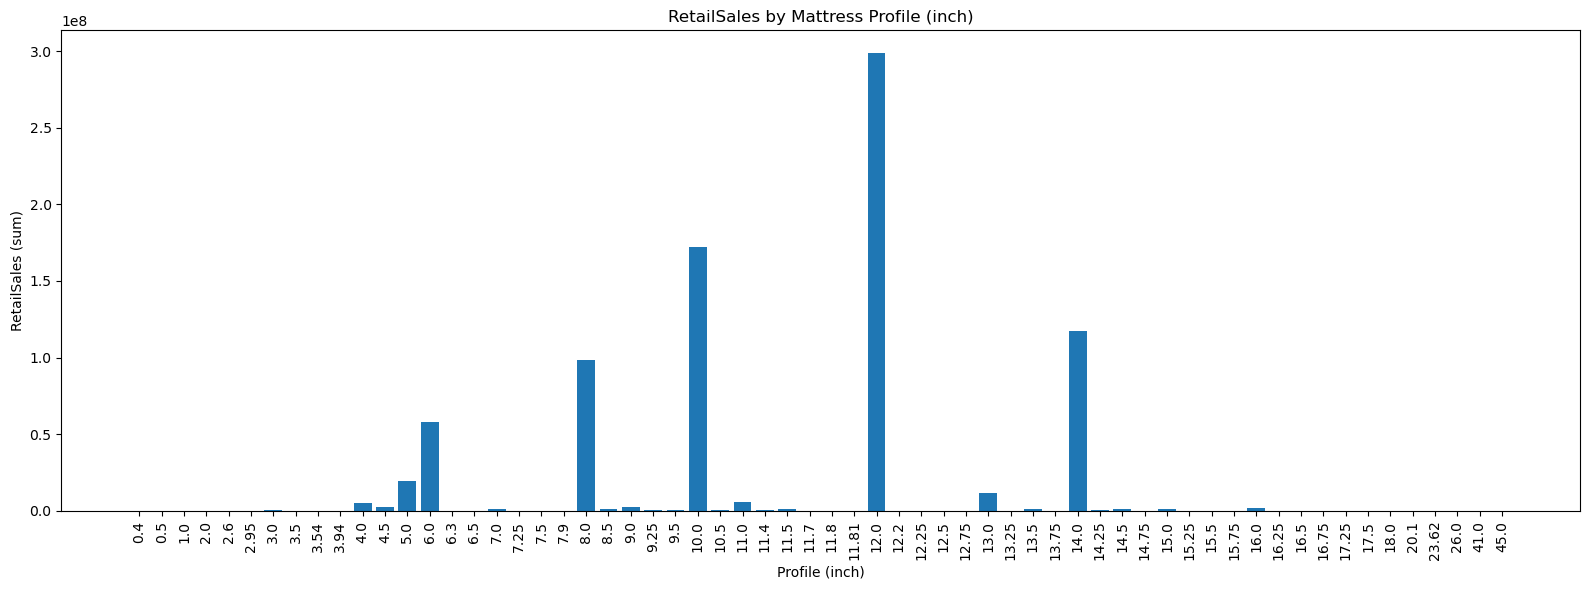

In [279]:
# 2025년 데이터 필터링 (df1에서)
df_mattress = df1[df1['year']==2025].copy()

# profile 값 전처리
df_mattress['profile'] = pd.to_numeric(df_mattress['profile'], errors='coerce')
df_mattress = df_mattress[df_mattress['profile'].notnull()]

# 각 profile(inch) 별 RetailSales 합계 집계
sales_by_profile = (
    df_mattress
    .groupby('profile')['RetailSales']
    .sum()
    .reset_index()
    .sort_values('profile')
)

# Plot
plt.figure(figsize=(16, 6))
plt.bar(sales_by_profile['profile'].astype(str), sales_by_profile['RetailSales'])
plt.xlabel('Profile (inch)')
plt.ylabel('RetailSales (sum)')
plt.title('RetailSales by Mattress Profile (inch)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

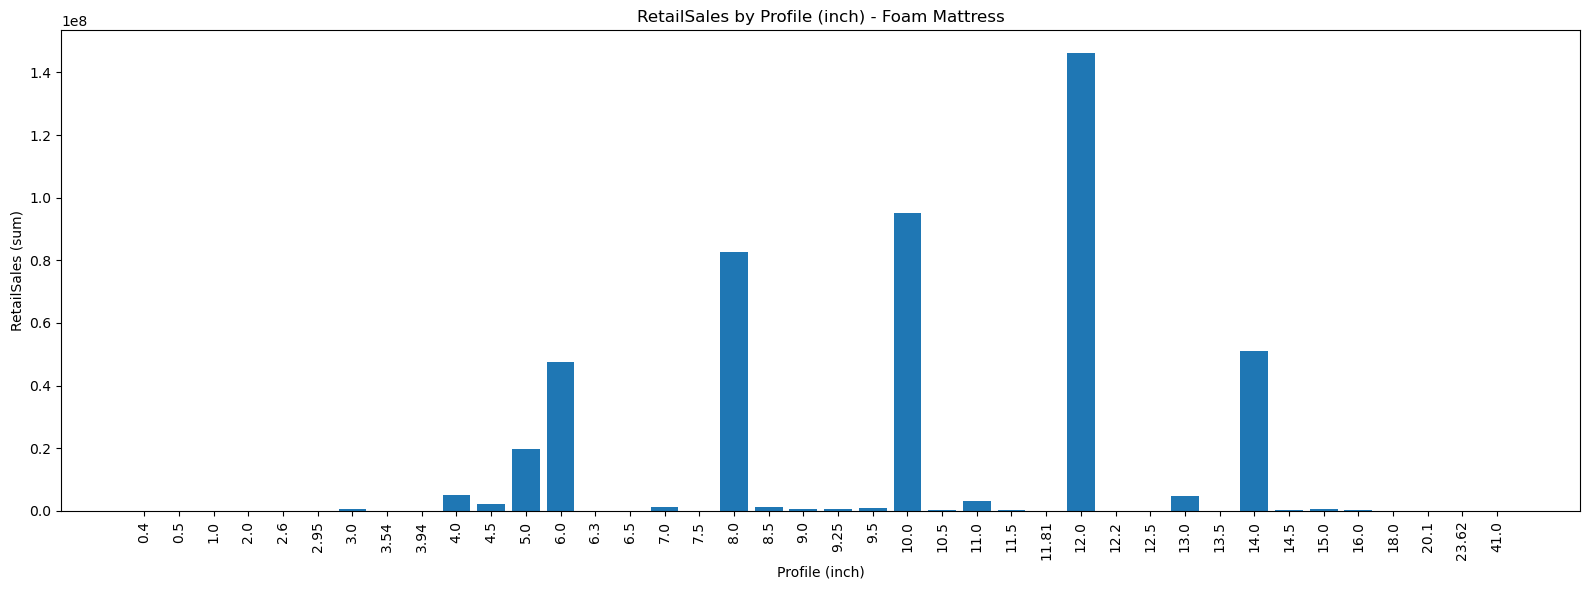

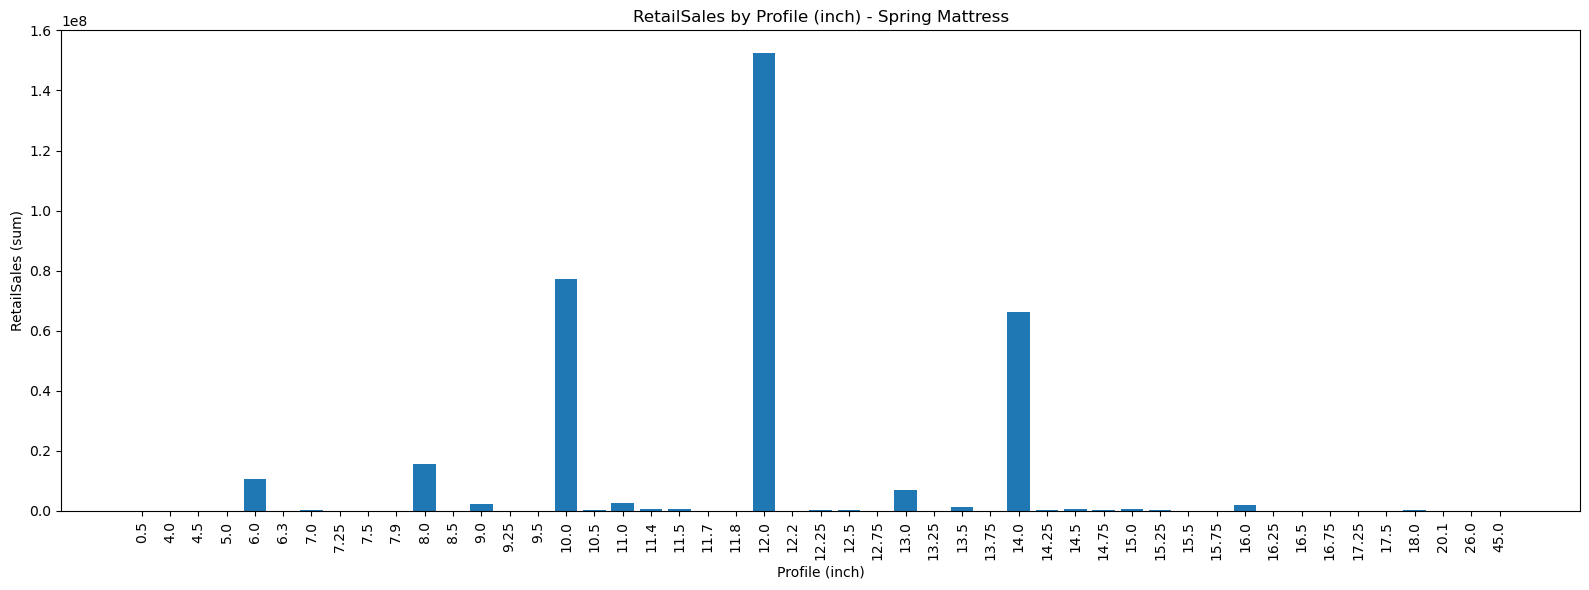

In [281]:
# 2025년 데이터 필터링
df_mattress = df1[df1['year']==2025].copy()

# profile 값 전처리
df_mattress['profile'] = pd.to_numeric(df_mattress['profile'], errors='coerce')
df_mattress = df_mattress[df_mattress['profile'].notnull()]

# 각 카테고리별로 반복
for cat in ['Foam Mattress', 'Spring Mattress']:
    df_cat = df_mattress[df_mattress['category'] == cat]

    sales_by_profile = (
        df_cat
        .groupby('profile')['RetailSales']
        .sum()
        .reset_index()
        .sort_values('profile')
    )

    plt.figure(figsize=(16, 6))
    plt.bar(sales_by_profile['profile'].astype(str), sales_by_profile['RetailSales'])
    plt.xlabel('Profile (inch)')
    plt.ylabel('RetailSales (sum)')
    plt.title(f'RetailSales by Profile (inch) - {cat}')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

#### 2.4 Size별 분석하기

In [284]:
df_2025 = df1[df1['year'] == 2025].copy()

In [290]:
size_group = df_2025.groupby('size').agg(sku_count=('RetailerSku','nunique'), total_sales=('RetailSales','sum'))
print(size_group)

               sku_count  total_sales
size                                 
-                      1      4348.80
24" x 72"             13     14267.17
24" x 78"              1      1024.95
25-Inch                3     36697.70
28 x 75                1       639.45
...                  ...          ...
Twin                1559  33723906.31
Twin & Full            1     12811.12
Twin Set of 2          1     13297.51
Twin Wide              1       489.00
Twin XL              666   9716006.53

[182 rows x 2 columns]


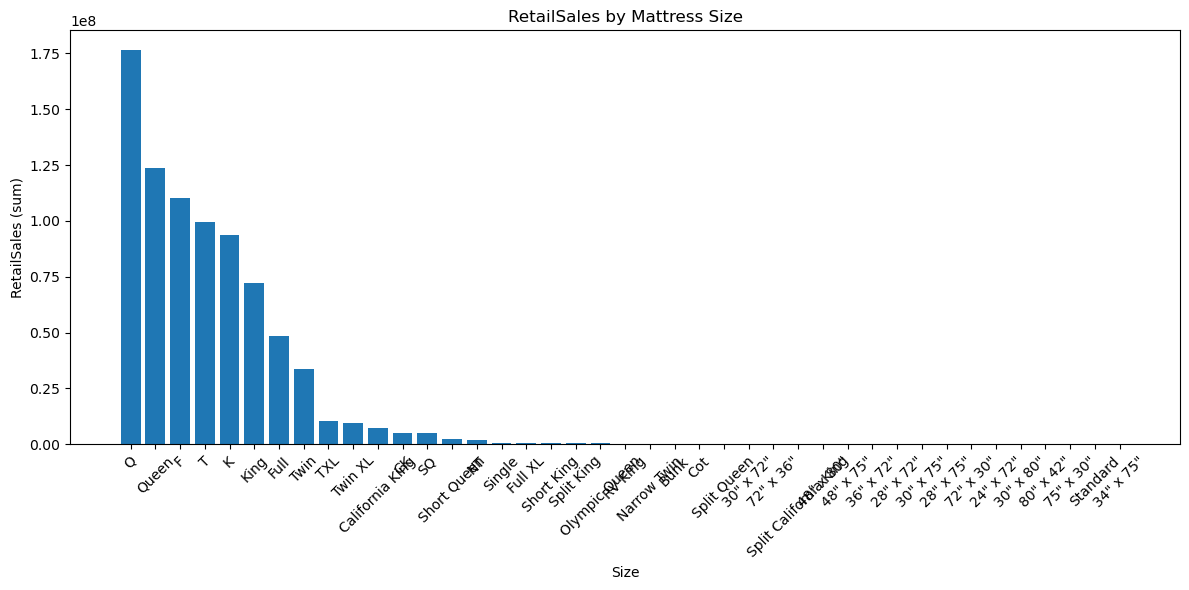

In [306]:
size_group = (
    df_2025.groupby('size')
    .agg(sku_count=('RetailerSku','nunique'), total_sales=('RetailSales','sum'))
    .reset_index()
    .sort_values(by='total_sales', ascending=False)
)

# sku_count가 1 초과인 경우만 필터링
size_group = size_group[size_group['sku_count'] > 5]
plt.figure(figsize=(12, 6))
plt.bar(size_group['size'].astype(str), size_group['total_sales'])
plt.xlabel('Size')
plt.ylabel('RetailSales (sum)')
plt.title('RetailSales by Mattress Size')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [302]:
print(size_group)

          size  sku_count  total_sales
1    24" x 72"         13     14267.17
3      25-Inch          3     36697.70
6    28" x 72"         19     21282.53
7    28" x 73"          5      2704.81
8    28" x 75"          6     17552.38
..         ...        ...          ...
171   Standard          6      5734.01
172          T        390  99677886.59
173        TXL        109  10324388.37
177       Twin       1559  33723906.31
181    Twin XL        666   9716006.53

[61 rows x 3 columns]


### Weekly 히트맵 구하기

C:\Users\최태욱\AppData\Local\Temp\ipykernel_24044\1417810743.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_filtered.groupby('PriceBin')['UnitsSold']


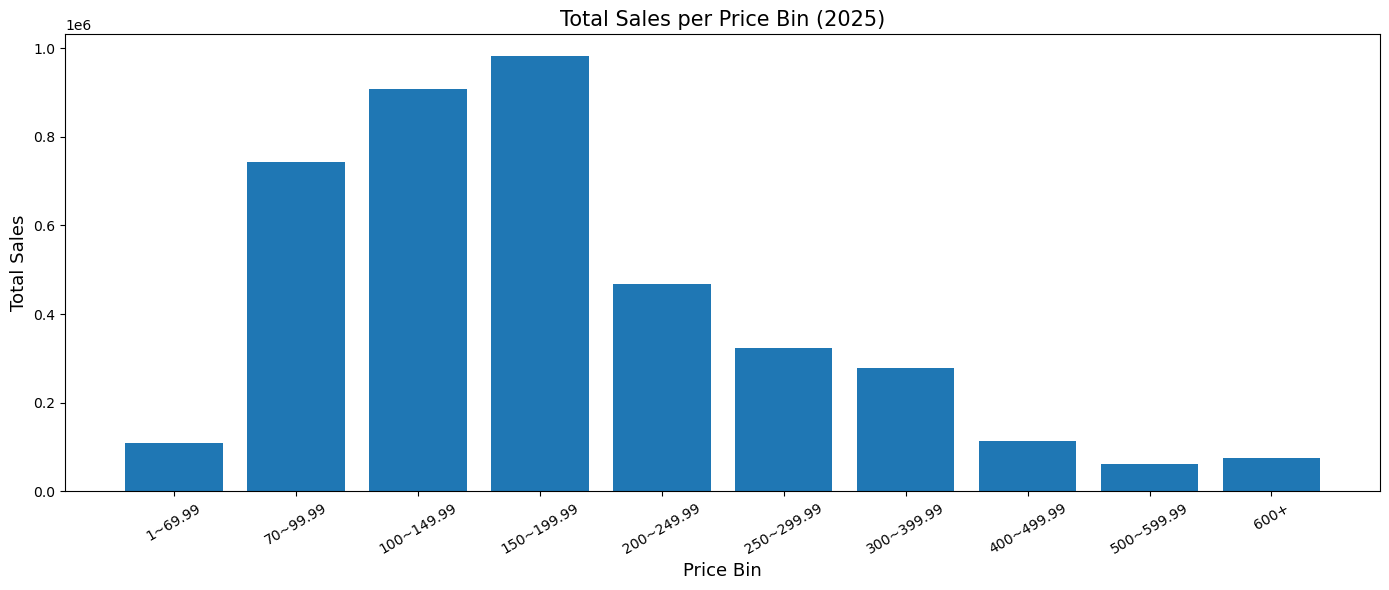

In [59]:
# 1. 2025년 + OTHERS 제외
df_filtered = df[
    (df['category'] != 'OTHERS') &
    (df['year'] == 2025)
].copy()

# 2. Price Bin 직접 정의
price_bins = [1, 70, 100, 150, 200, 250, 300, 400, 500, 600, np.inf]
bin_labels = [ "1~69.99", "70~99.99", "100~149.99", "150~199.99",
    "200~249.99", "250~299.99", "300~399.99", "400~499.99",
    "500~599.99", "600+"
]

# 3. 가격 버킷 할당
df_filtered['PriceBin'] = pd.cut(
    df_filtered['RetailPrice'],
    bins=price_bins,
    labels=bin_labels,
    right=False,   # 왼쪽 포함, 오른쪽 미포함 (1~50은 1 <= x < 50)
    include_lowest=True
)

# 4. Price Bin별 매출 합계 집계
sales_by_bin = (
   # df_filtered.groupby('PriceBin')['RetailSales']
    df_filtered.groupby('PriceBin')['UnitsSold']
    .sum()
    .reindex(bin_labels)  # 빈 구간도 포함
)

# 5. 히스토그램(막대그래프) 시각화
plt.figure(figsize=(14,6))
plt.bar(sales_by_bin.index, sales_by_bin.values)
plt.xlabel("Price Bin", fontsize=13)
plt.ylabel("Total Sales", fontsize=13)
plt.title("Total Sales per Price Bin (2025)", fontsize=15)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

C:\Users\최태욱\AppData\Local\Temp\ipykernel_31916\271820143.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_filtered.groupby(['PriceBin', 'yr_week'])['RetailSales']


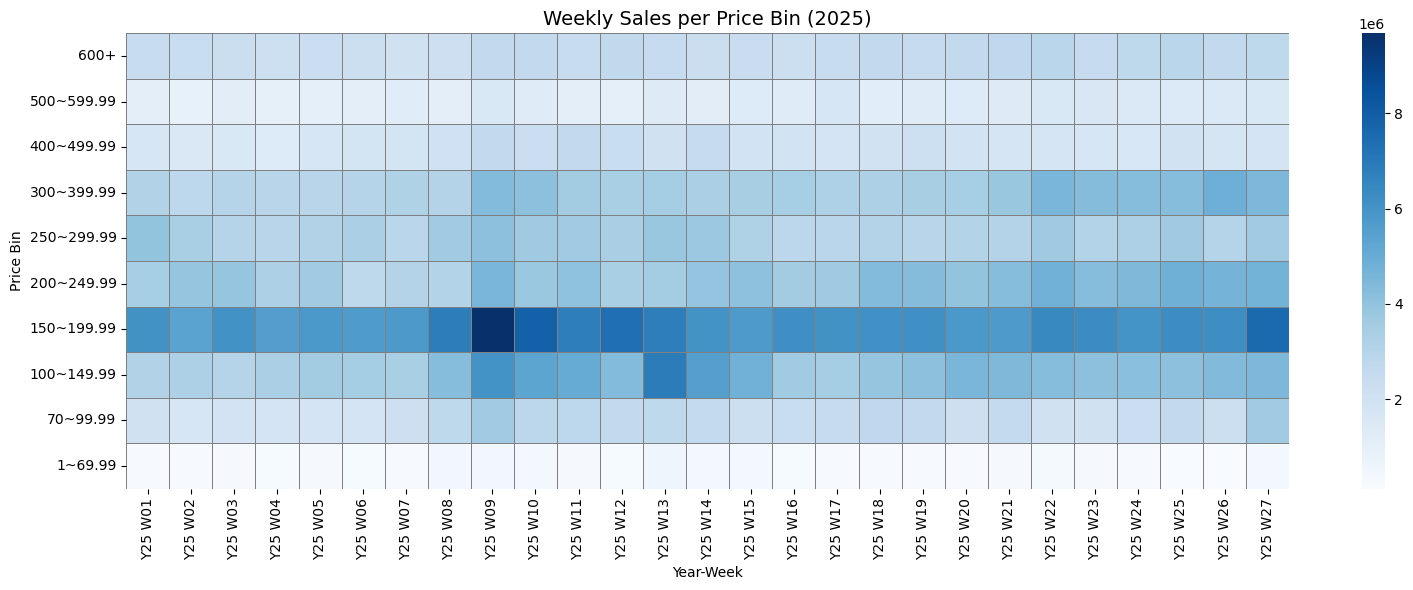

In [194]:
# 1. 2025년 + OTHERS 제외
df_filtered = df[
    (df['category'] != 'OTHERS') &
    (df['year'] == 2025)
].copy()

# 2. Price Bin 직접 정의
price_bins = [1, 70, 100, 150, 200, 250, 300, 400, 500, 600, np.inf]
bin_labels = [
    "1~69.99", "70~99.99", "100~149.99", "150~199.99",
    "200~249.99", "250~299.99", "300~399.99", "400~499.99",
    "500~599.99", "600+"
]

# 3. 가격 버킷 할당
df_filtered['PriceBin'] = pd.cut(
    df_filtered['RetailPrice'],
    bins=price_bins,
    labels=bin_labels,
    right=False,
    include_lowest=True
)

# 4. Y축(Price Bin), X축(yr_week) 별 매출 집계
heatmap_data = (
    df_filtered.groupby(['PriceBin', 'yr_week'])['RetailSales']
    .sum()
    .unstack(fill_value=0)
    .reindex(index=bin_labels[::-1])  # Y축 구간 순서 고정
)

# 5. 히트맵 시각화
plt.figure(figsize=(16, 6))
sns.heatmap(
    heatmap_data,
    cmap="Blues",
    linewidths=0.5,
    linecolor='gray'
)

plt.title("Weekly Sales per Price Bin (2025)", fontsize=14)
plt.xlabel("Year-Week")
plt.ylabel("Price Bin")
plt.tight_layout()
plt.show()

C:\Users\최태욱\AppData\Local\Temp\ipykernel_31916\1939044259.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cat.groupby(['PriceBin', 'yr_week'])['RetailSales']


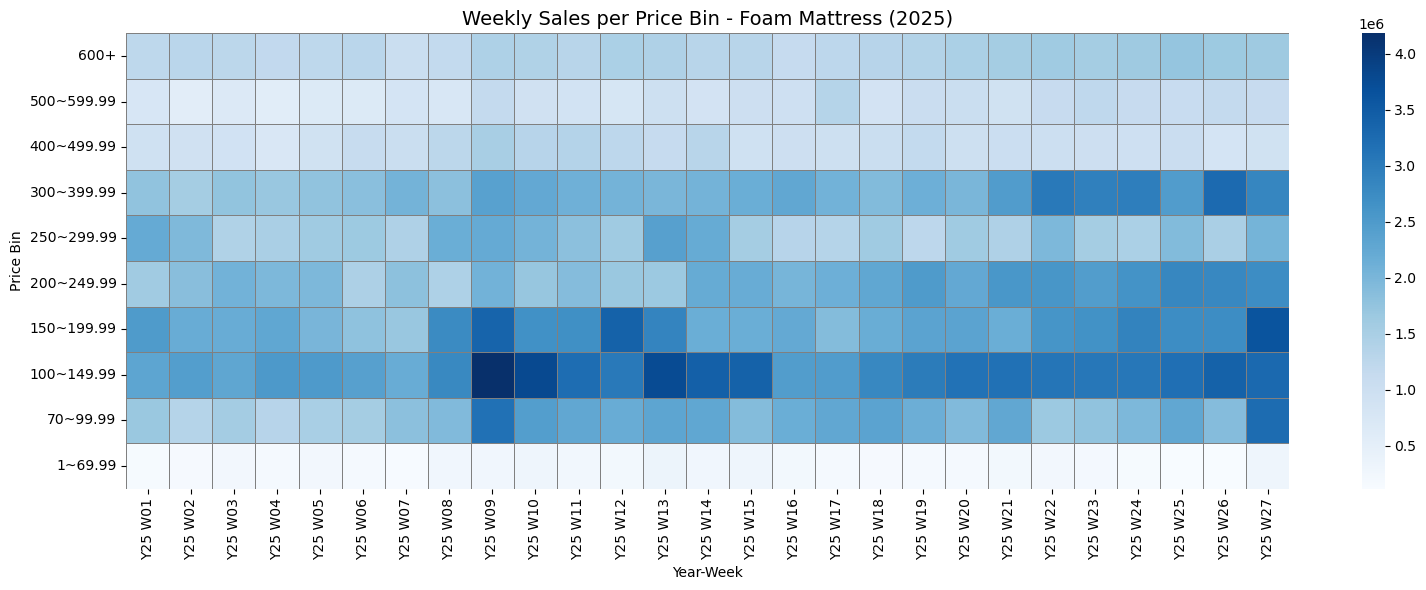

C:\Users\최태욱\AppData\Local\Temp\ipykernel_31916\1939044259.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cat.groupby(['PriceBin', 'yr_week'])['RetailSales']


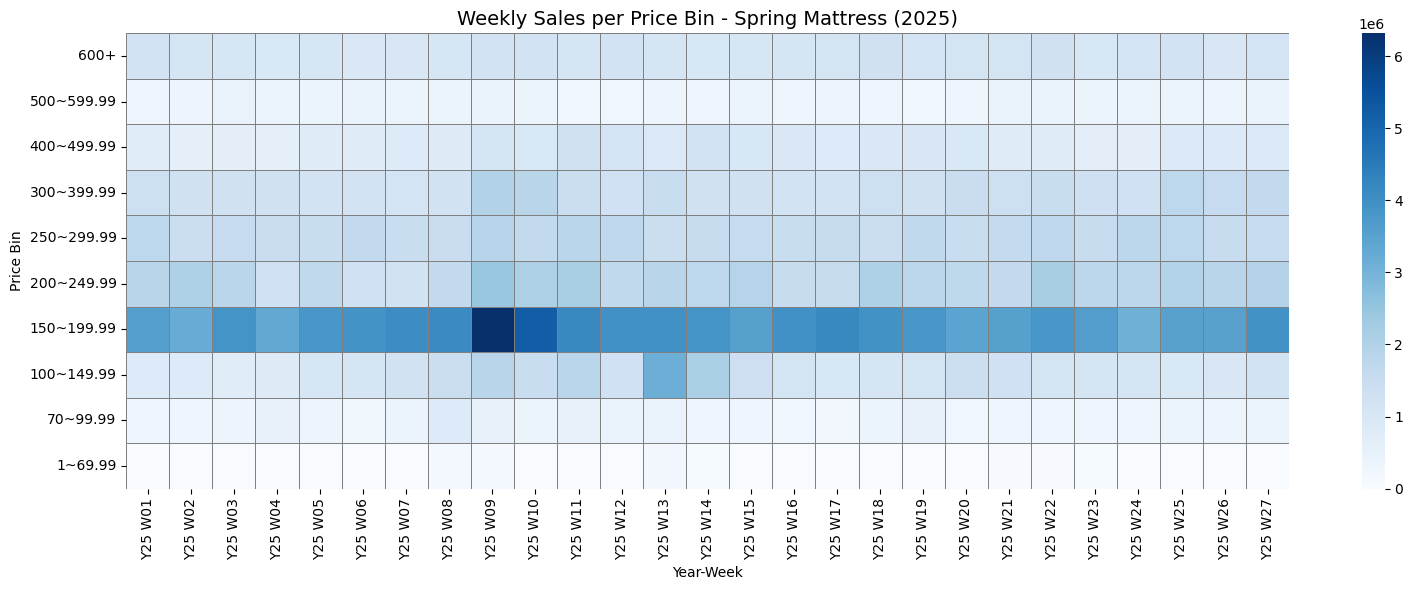

In [206]:
# Price Bin 설정
price_bins = [1, 70, 100, 150, 200, 250, 300, 400, 500, 600, np.inf]
bin_labels = [
    "1~69.99", "70~99.99", "100~149.99", "150~199.99",
    "200~249.99", "250~299.99", "300~399.99", "400~499.99",
    "500~599.99", "600+"
]

def draw_heatmap(df, category_name):
    df_cat = df[
        (df['category'] == category_name) & (df['year'] == 2025)
    ].copy()
    if len(df_cat) == 0:
        print(f"No data for {category_name}")
        return
    df_cat['PriceBin'] = pd.cut(
        df_cat['RetailPrice'],
        bins=price_bins,
        labels=bin_labels,
        right=False,
        include_lowest=True
    )
    all_weeks = sorted(df_cat['yr_week'].unique())
    heatmap_data = (
        df_cat.groupby(['PriceBin', 'yr_week'])['RetailSales']
        .sum()
        .unstack(fill_value=0)
        .reindex(index=bin_labels[::-1], columns=all_weeks, fill_value=0)
    )
    plt.figure(figsize=(16, 6))
    sns.heatmap(
        heatmap_data,
        cmap="Blues",
        linewidths=0.5,
        linecolor='gray'
    )
    plt.title(f"Weekly Sales per Price Bin - {category_name} (2025)", fontsize=14)
    plt.xlabel("Year-Week")
    plt.ylabel("Price Bin")
    plt.tight_layout()
    plt.show()

# Foam Mattress
draw_heatmap(df, 'Foam Mattress')

# Spring Mattress
draw_heatmap(df, 'Spring Mattress')

C:\Users\최태욱\AppData\Local\Temp\ipykernel_31916\2227028325.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_filtered.groupby(['PriceBucket', 'yr_week'])['RetailSales']


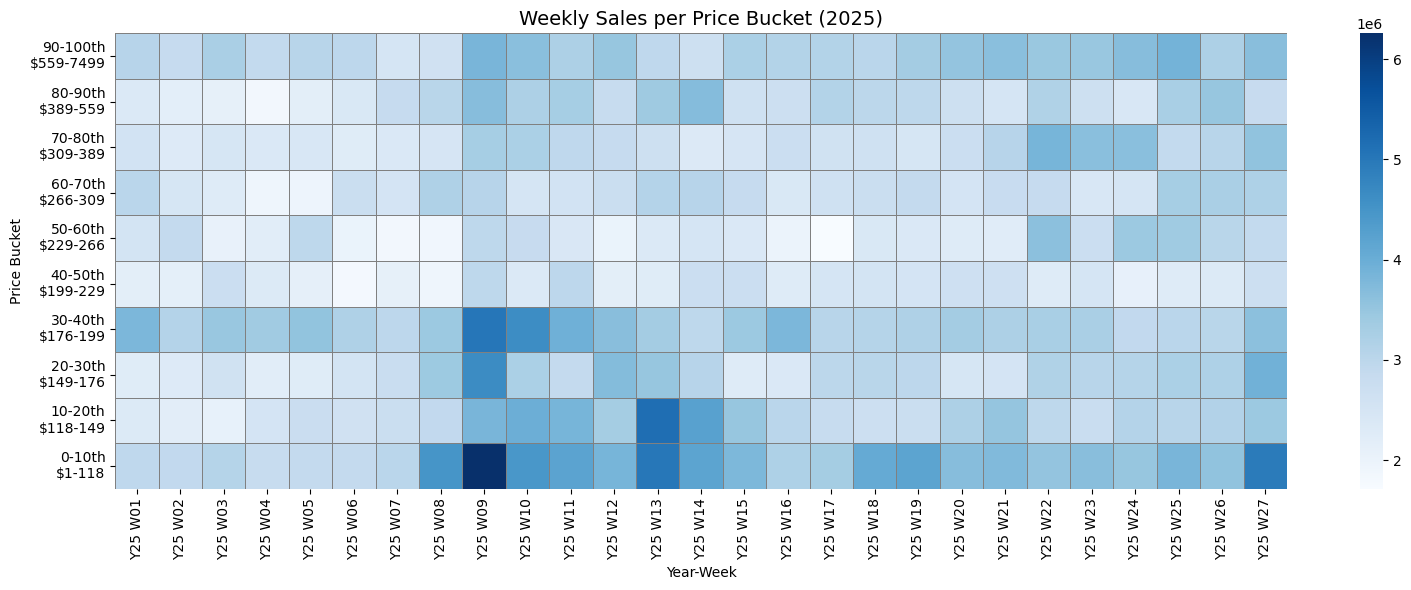

In [180]:

# 1. 2025년 + OTHERS 제외
df_filtered = df[
    (df['category'] != 'OTHERS') &
    (df['year'] == 2025) #&
    #(df['Brand_raw'] == 'ZINUS')
].copy()

# 2. 가격 퍼센타일 구간 계산 (2025년 전체 기준)
price_base = df_filtered['RetailPrice'].dropna()
percentiles = np.arange(0, 101, 10)
price_bins = np.percentile(price_base, q=percentiles)

bucket_labels = [
    f"{percentiles[i]}-{percentiles[i+1]}th\n${int(price_bins[i])}-{int(price_bins[i+1])}"
    for i in range(len(price_bins) - 1)
]

# 3. 가격 버킷 할당
df_filtered['PriceBucket'] = pd.cut(
    df_filtered['RetailPrice'],
    bins=price_bins,
    labels=bucket_labels,
    include_lowest=True
)

# ✅ Y축 가격대 내림차순 정렬
df_filtered['PriceBucket'] = pd.Categorical(
    df_filtered['PriceBucket'],
    categories=bucket_labels[::-1],
    ordered=True
)

# ✅ 4. 가격대 × 주차별 매출 집계
heatmap_data = (
    df_filtered.groupby(['PriceBucket', 'yr_week'])['RetailSales']
               .sum()
               .unstack(fill_value=0)
)

# ✅ 5. 히트맵 시각화
plt.figure(figsize=(16, 6))
sns.heatmap(
    heatmap_data,
    cmap="Blues",
    linewidths=0.5,
    linecolor='gray'
)

plt.title("Weekly Sales per Price Bucket (2025)", fontsize=14)
plt.xlabel("Year-Week")
plt.ylabel("Price Bucket")
plt.tight_layout()
plt.show()

C:\Users\최태욱\AppData\Local\Temp\ipykernel_24044\3585644296.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cat.groupby(['PriceBucket', 'yr_week'])['UnitsSold']


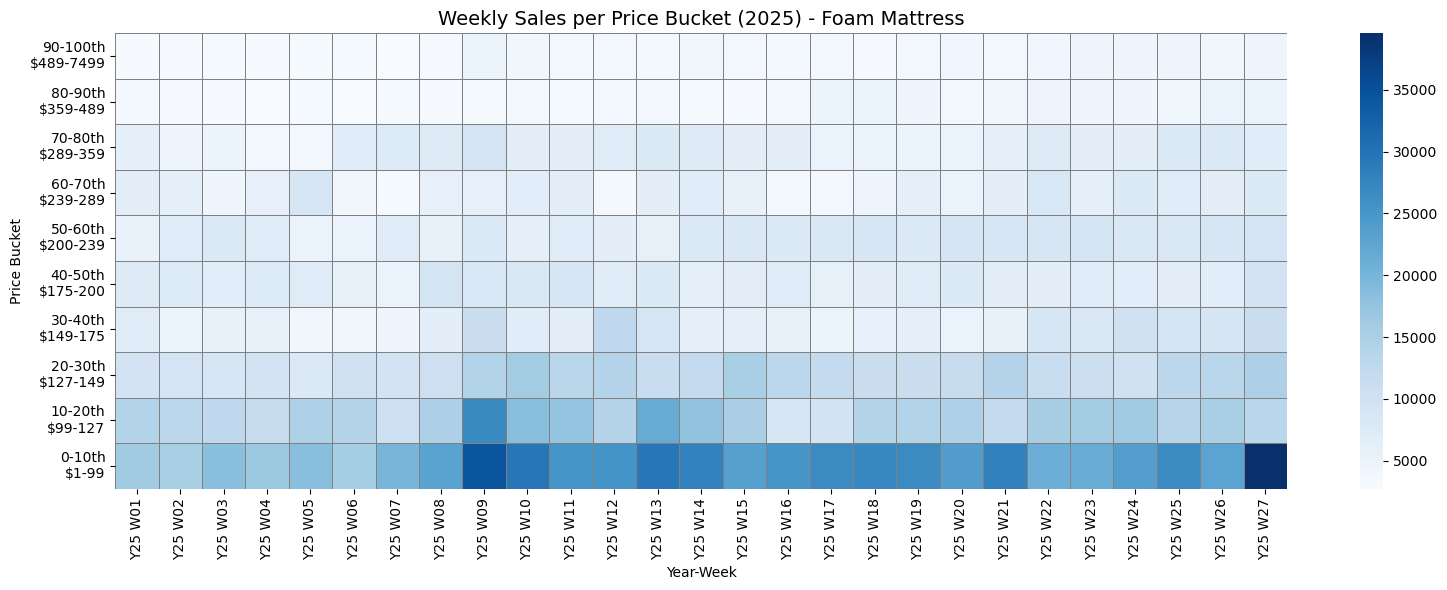

C:\Users\최태욱\AppData\Local\Temp\ipykernel_24044\3585644296.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cat.groupby(['PriceBucket', 'yr_week'])['UnitsSold']


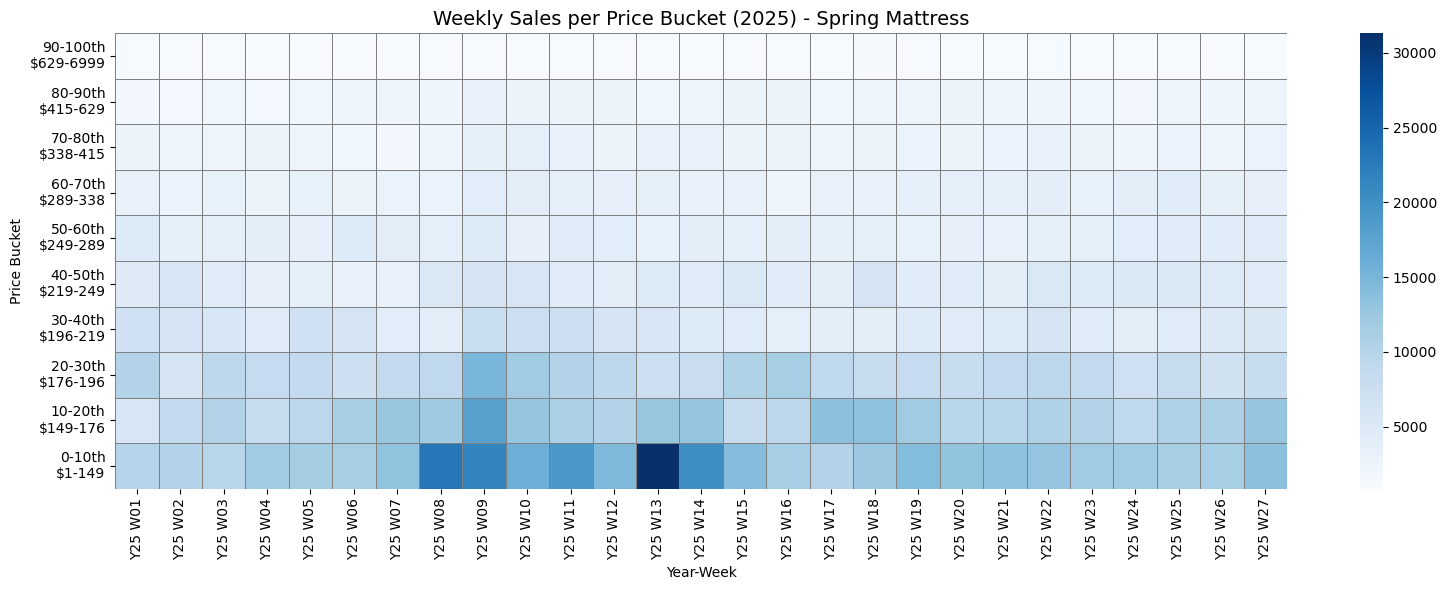

In [41]:

# 전처리: OTHERS 제외, 2025년만
df_filtered = df[
    (df['category'] != 'OTHERS') &
    (df['year'] == 2025)
].copy()

category_list = ['Foam Mattress', 'Spring Mattress']

for cat in category_list:
    df_cat = df_filtered[df_filtered['category'] == cat].copy()
    # 가격 퍼센타일 구간 (해당 카테고리에서만)
    price_base = df_cat['RetailPrice'].dropna()
    if len(price_base) < 2:
        print(f"{cat} 데이터가 충분하지 않습니다.")
        continue

    percentiles = np.arange(0, 101, 10)
    price_bins = np.percentile(price_base, q=percentiles)
    # 동일 가격 구간이 있으면 에러 발생 → 중복 제거
    price_bins = np.unique(price_bins)
    # 라벨 재생성 (bin 길이에 맞게)
    bucket_labels = [
        f"{i*10}-{(i+1)*10}th\n${int(price_bins[i])}-{int(price_bins[i+1])}"
        for i in range(len(price_bins) - 1)
    ]

    # 가격 버킷 할당
    df_cat['PriceBucket'] = pd.cut(
        df_cat['RetailPrice'],
        bins=price_bins,
        labels=bucket_labels,
        include_lowest=True
    )
    df_cat['PriceBucket'] = pd.Categorical(
        df_cat['PriceBucket'],
        categories=bucket_labels[::-1],
        ordered=True
    )

    # 히트맵용 데이터
    heatmap_data = (
        #df_cat.groupby(['PriceBucket', 'yr_week'])['RetailSales']
        df_cat.groupby(['PriceBucket', 'yr_week'])['UnitsSold']
              .sum()
              .unstack(fill_value=0)
    )

    plt.figure(figsize=(16, 6))
    sns.heatmap(
        heatmap_data,
        cmap="Blues",
        linewidths=0.5,
        linecolor='gray'
    )
    plt.title(f"Weekly Sales per Price Bucket (2025) - {cat}", fontsize=14)
    plt.xlabel("Year-Week")
    plt.ylabel("Price Bucket")
    plt.tight_layout()
    plt.show()

In [53]:
# PriceBucket 카테고리 오름차순으로 지정
df_filtered['PriceBucket'] = pd.Categorical(
    df_filtered['PriceBucket'],
    categories=bucket_labels,   # 오름차순
    ordered=True
)

# 오름차순 PriceBin 순서로 매출 집계
sales_by_bin = (
    df_filtered.groupby('PriceBucket')['RetailSales']
    .sum()
    .reindex(bucket_labels)     # 오름차순으로 정렬
)

# 막대그래프 시각화
plt.figure(figsize=(12, 6))
sales_by_bin.plot(kind='bar')

plt.title("Total Sales by Price Bin (2025)", fontsize=14)
plt.xlabel("Price Bin")
plt.ylabel("Total Sales")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

KeyError: 'PriceBucket'

In [43]:
# PriceBucket 카테고리 오름차순으로 지정
df_filtered['PriceBucket'] = pd.Categorical(
    df_filtered['PriceBucket'],
    categories=bucket_labels,   # 오름차순
    ordered=True
)

# 오름차순 PriceBin 순서로 매출 집계
sales_by_bin = (
    df_filtered.groupby('PriceBucket')['UnitsSold']
    .sum()
    .reindex(bucket_labels)     # 오름차순으로 정렬
)

# 막대그래프 시각화
plt.figure(figsize=(12, 6))
sales_by_bin.plot(kind='bar')

plt.title("Total Sales by Price Bin (2025)", fontsize=14)
plt.xlabel("Price Bin")
plt.ylabel("Total Sales Units")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

KeyError: 'PriceBucket'

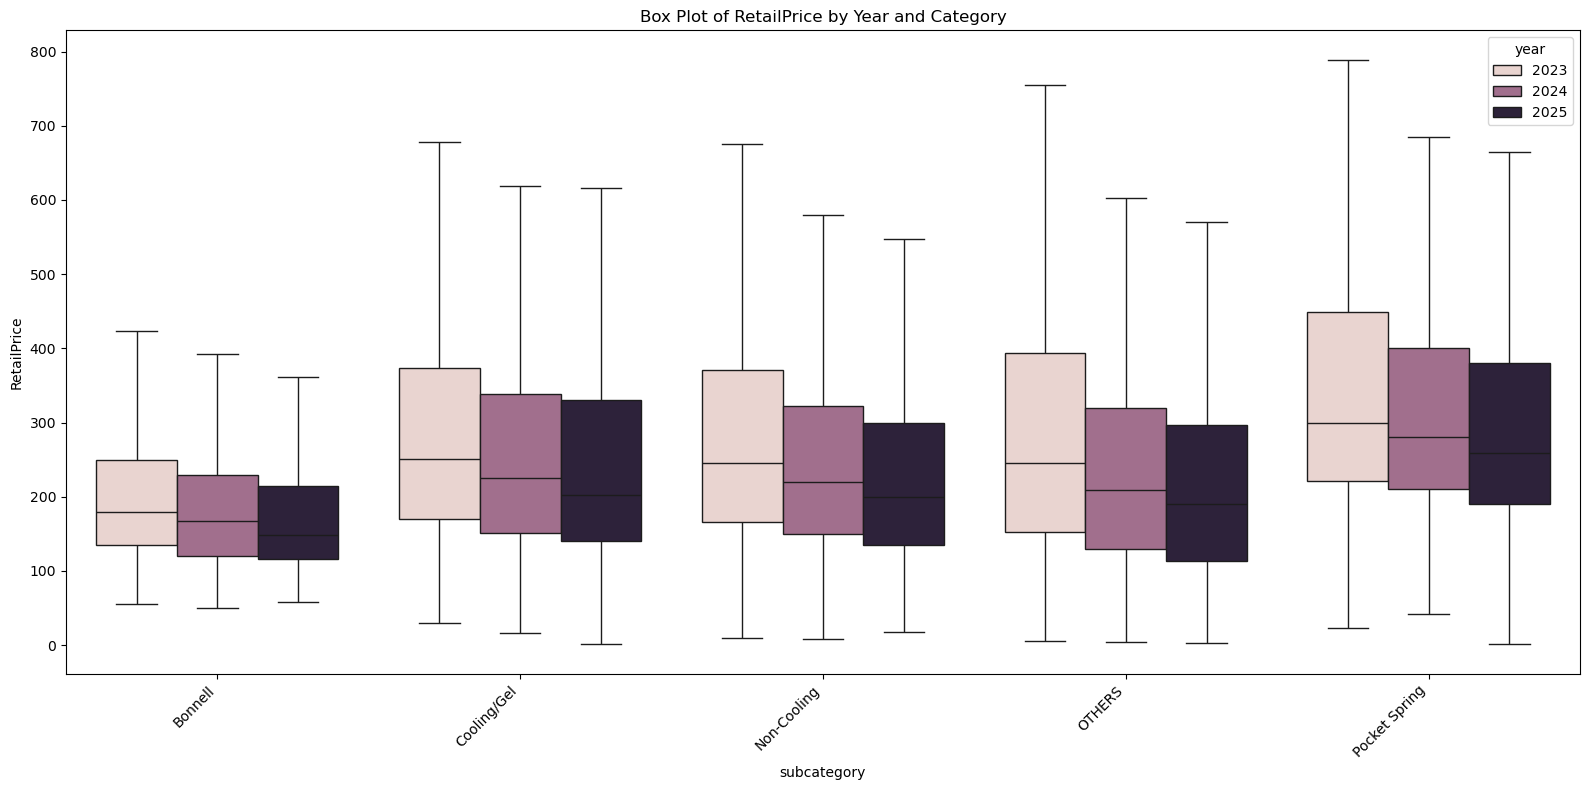

In [102]:

plt.figure(figsize=(16, 8))
sns.boxplot(
    data=df[df['RetailPrice'] > 0],  # 0 이하 제외 (로그변환 등에도 안전)
    x='subcategory',
    y='RetailPrice',
    hue='year',        # 분기로 색 구분
    showfliers=False         # 이상치 점 표시 안함 (원하면 True로)
)

plt.xticks(rotation=45, ha='right')
plt.title('Box Plot of RetailPrice by Year and Category')
plt.ylabel('RetailPrice')
plt.tight_layout()
plt.legend(title='year')
plt.show()

### Brand 별 매출 구하기

In [164]:
# 1. 2025년 데이터 필터링
df_2025 = df[df['year'] == 2025].copy()

# 2. Brand_raw별 매출 합계 집계
brand_sales_2025 = (
    df_2025.groupby('Brand_raw')['RetailSales']
           .sum()
           .reset_index()
           .sort_values(by='RetailSales', ascending=False)
)

# 3. CSV로 저장
brand_sales_2025.to_csv('brand_sales_2025_sorted.csv', index=False)

# (선택) 상위 5개 출력
print(brand_sales_2025.head())

    Brand_raw   RetailSales
610     ZINUS  1.401663e+08
386   NOVILLA  6.276125e+07
168       FDW  3.963378e+07
352     MLILY  3.545190e+07
375    NECTAR  3.312092e+07


In [166]:
print(brand_sales_2025['Brand_raw'].nunique())

619
